# Import Files & APIs #

In [1]:
from glob import glob
from xarray import open_mfdataset
from warnings import filterwarnings
import matplotlib.pyplot as plt
import numpy as np
import scipy.io
import pandas as pd
from scipy.stats import pearsonr
from sklearn.metrics import mean_squared_error
%matplotlib inline
import math
filterwarnings('ignore')

In [2]:
example_d = "./test_data_2022/ucar_*.nc"
example_f = sorted(glob(example_d)) # finds files recursively

xds = open_mfdataset(example_f, combine="by_coords",  parallel=True)

# Data Exploration #

In [3]:
# See what is in files
xds

<xarray.Dataset> Size: 3GB
Dimensions:         (time: 360, timeslices: 4, lat: 252, lon: 802, startstop: 2)
Coordinates:
  * time            (time) datetime64[ns] 3kB 2022-01-01T12:00:00 ... 2022-12...
Dimensions without coordinates: timeslices, lat, lon, startstop
Data variables:
    SM_subdaily     (time, timeslices, lat, lon) float32 1GB dask.array<chunksize=(1, 4, 252, 802), meta=np.ndarray>
    SIGMA_subdaily  (time, timeslices, lat, lon) float32 1GB dask.array<chunksize=(1, 4, 252, 802), meta=np.ndarray>
    longitude       (time, lat, lon) float32 291MB dask.array<chunksize=(1, 252, 802), meta=np.ndarray>
    latitude        (time, lat, lon) float32 291MB dask.array<chunksize=(1, 252, 802), meta=np.ndarray>
    timeintervals   (time, timeslices, startstop) timedelta64[ns] 23kB dask.array<chunksize=(1, 4, 2), meta=np.ndarray>
    SM_daily        (time, lat, lon) float32 291MB dask.array<chunksize=(1, 252, 802), meta=np.ndarray>
    SIGMA_daily     (time, lat, lon) float32 291MB dask.array<chunksize=(1, 252, 802), meta=np.ndarray>
Attributes: (12/45)
    source:                              ucar_cu_cygnss_sm_v1_2022_001.nc
    id:                                  PODAAC-CYGNU-L3SM1
    ShortName:                           CYGNSS_L3_SOIL_MOISTURE_V1.0
    title:                               CYGNSS Level 3 Soil Moisture from UC...
    summary:                             The CYGNSS Level 3 Soil Moisture Pro...
    comment:                             Dataset created by UCAR and CU Boulder
    ...                                  ...
    build_dmrpp_metadata.build_dmrpp:    3.20.9-91
    build_dmrpp_metadata.bes:            3.20.9-91
    build_dmrpp_metadata.libdap:         libdap-3.20.8-41
    build_dmrpp_metadata.configuration:  \n# TheBESKeys::get_as_config()\nAll...
    build_dmrpp_metadata.invocation:     build_dmrpp -c /tmp/conf_Jpyz -f /tm...
    history_json:                        [{"$schema":"https:\/\/harmony.earth...

In [4]:
# See what longitude and latitude variables store
latitudes = xds['latitude'].values
longitudes = xds['longitude'].values

print("latitude values:", latitudes[0])
print("\nlongitude values:", longitudes[0])
print("\nlatitude shape:", latitudes.shape)
print("longitude shape:", longitudes.shape)

# Notes:
# Seems like the latitude and longitude values are sorted into an array such that all of the 
# coordinates can be accessed by using a simple 2D array traversal. They are the shape 252 x 802
# since there are 252 available latitude values and 802 available longitude values.

latitude values: [[-38.14157  -38.14157  -38.14157  ... -38.14157  -38.14157  -38.14157 ]
 [-37.785137 -37.785137 -37.785137 ... -37.785137 -37.785137 -37.785137]
 [-37.430386 -37.430386 -37.430386 ... -37.430386 -37.430386 -37.430386]
 ...
 [ 37.430386  37.430386  37.430386 ...  37.430386  37.430386  37.430386]
 [ 37.785137  37.785137  37.785137 ...  37.785137  37.785137  37.785137]
 [ 38.14157   38.14157   38.14157  ...  38.14157   38.14157   38.14157 ]]

longitude values: [[-135.      -134.62656 -134.25311 ...  163.38174  163.75519  164.12863]
 [-135.      -134.62656 -134.25311 ...  163.38174  163.75519  164.12863]
 [-135.      -134.62656 -134.25311 ...  163.38174  163.75519  164.12863]
 ...
 [-135.      -134.62656 -134.25311 ...  163.38174  163.75519  164.12863]
 [-135.      -134.62656 -134.25311 ...  163.38174  163.75519  164.12863]
 [-135.      -134.62656 -134.25311 ...  163.38174  163.75519  164.12863]]

latitude shape: (360, 252, 802)
longitude shape: (360, 252, 802)


In [5]:
# See what SM_daily variable stores
global_sm = xds['SM_daily'].values

l3_lat = 228
l3_lon = 107
l3_sm = []
for i in range(0,9):
    l3_sm.append((global_sm[i][l3_lat][l3_lon]))
l3_daily_sm = np.array(l3_sm)

print(l3_daily_sm)

# Notes:
# Pretty self-explanatory; these are the daily soil moisture values given i (the day) and the corresponding
# longitude and latitude coordinates, which are accessed by indexing the respective arrays.

[0.36138597 0.37076867        nan 0.347002   0.35713    0.34884498
 0.36342055 0.35879427        nan]


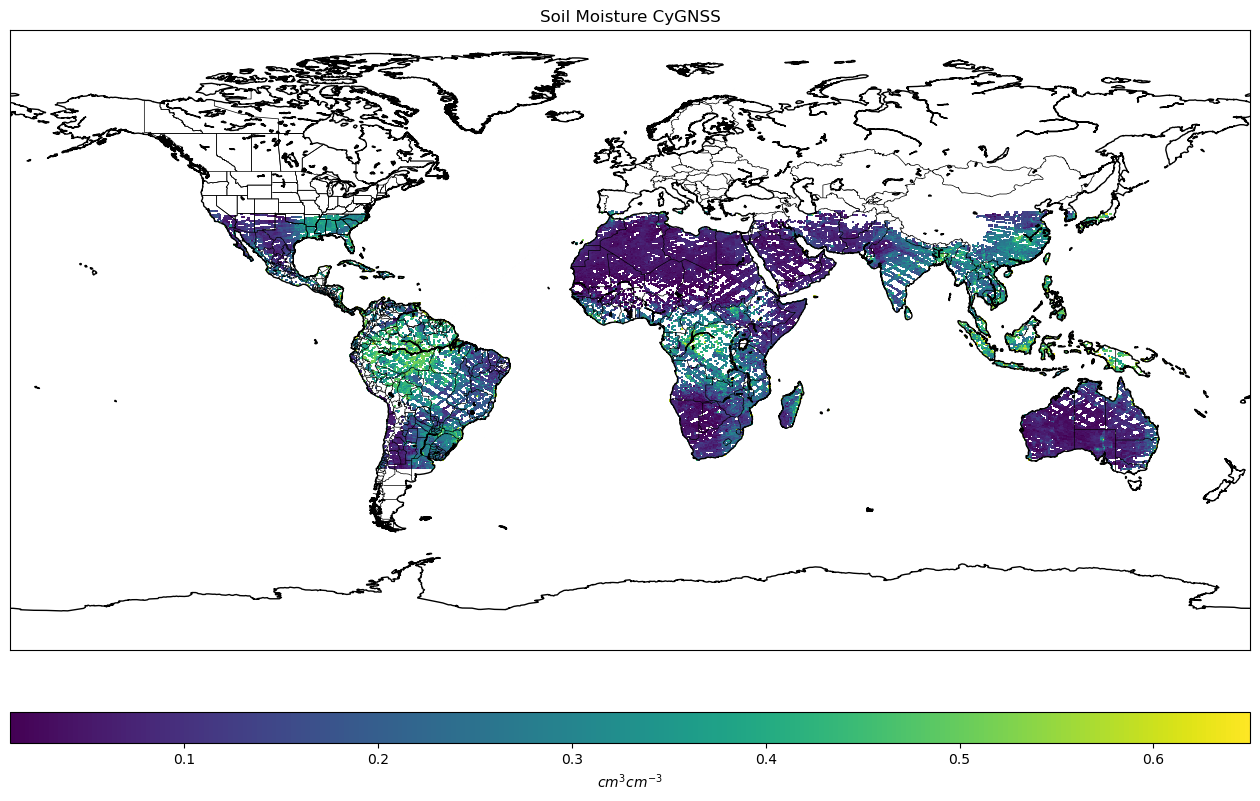

In [6]:
import matplotlib.pyplot as plt
from mpl_toolkits.basemap import Basemap
fig = plt.figure(figsize=(16, 12), edgecolor='w')

centre_lat = 30.311826
centre_lon = -98.775934
m = Basemap(width=5000000,height=3500000,
            resolution='l',projection='cyl',\
            lat_ts=0,lat_0=0.0,lon_0=0.0) 
xi, yi = longitudes[1,:,:], latitudes[1,:,:]
cs = m.pcolor(xi,yi,global_sm[1,:,:], latlon = True)

m.drawcoastlines()
m.drawstates()
m.drawcountries()
# Add Colorbar
cbar = m.colorbar(cs, location='bottom', pad="10%")
cbar.set_label('$cm^3 cm^{-3}$')

# Add Title
plt.title('Soil Moisture CyGNSS')

plt.show()

# Subdaily Soil Moisture Values #

## Time intervals ##

In [7]:
import datetime
time_intervals = xds['timeintervals'].values
print(time_intervals.shape)

timestamp = time_intervals[0][0][0]
print(type(timestamp))

for ts in time_intervals[0]:
    date = datetime.datetime.fromtimestamp(int(ts[0]) // 1000000000)
    print("ns:", ts[0])
    print("date:", date)

(360, 4, 2)
<class 'numpy.timedelta64'>
ns: 3600000000000 nanoseconds
date: 1969-12-31 19:00:00
ns: 4500000000000 nanoseconds
date: 1969-12-31 19:15:00
ns: 5400000000000 nanoseconds
date: 1969-12-31 19:30:00
ns: 6300000000000 nanoseconds
date: 1969-12-31 19:45:00


In [8]:
global_sm_subdaily = xds['SM_subdaily'].values
print(global_sm_subdaily.shape)

(360, 4, 252, 802)


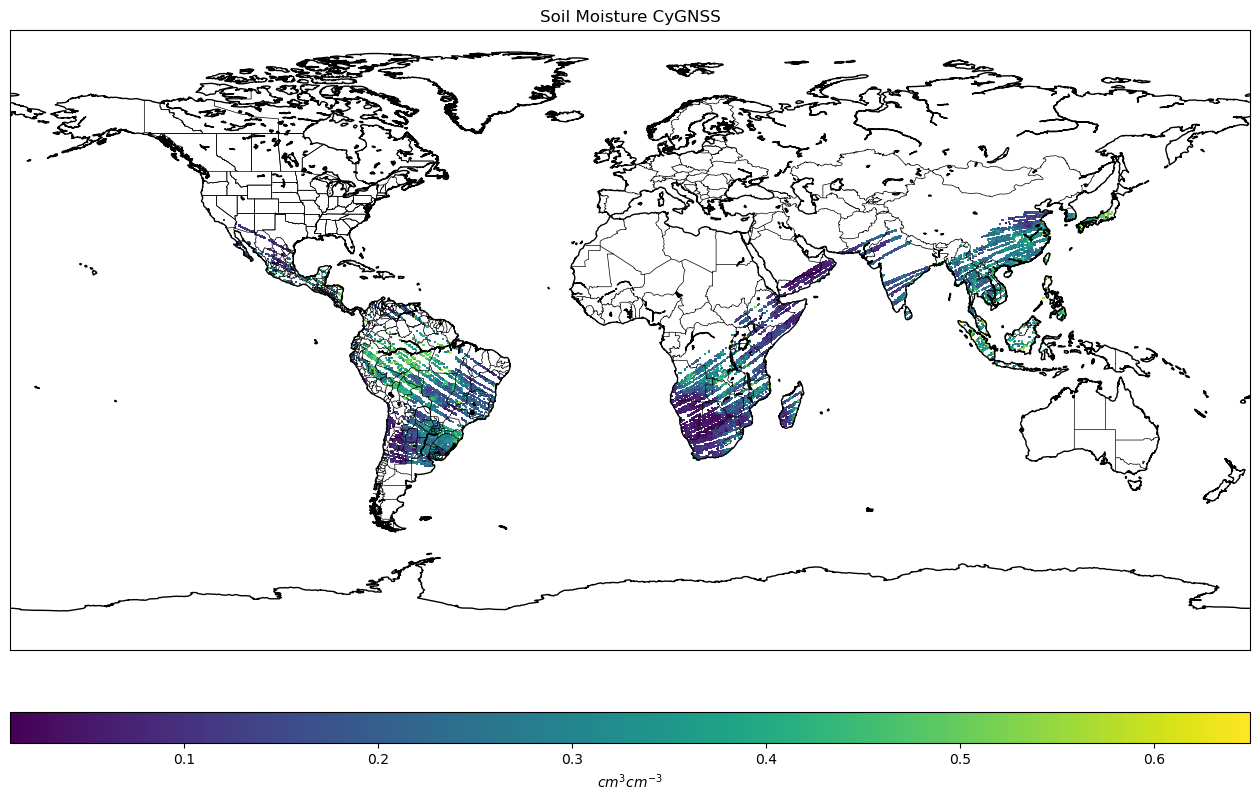

In [9]:
fig = plt.figure(figsize=(16, 12), edgecolor='w')

centre_lat = 30.311826
centre_lon = -98.775934
m = Basemap(width=5000000,height=3500000,
            resolution='l',projection='cyl',\
            lat_ts=0,lat_0=0.0,lon_0=0.0) 
xi, yi = longitudes[3,:,:], latitudes[3,:,:]
cs = m.pcolor(xi,yi,global_sm_subdaily[3,3,:,:], latlon = True)

m.drawcoastlines()
m.drawstates()
m.drawcountries()
# Add Colorbar
cbar = m.colorbar(cs, location='bottom', pad="10%")
cbar.set_label('$cm^3 cm^{-3}$')

# Add Title
plt.title('Soil Moisture CyGNSS')

plt.show()

As seen in the map above, there is not enough data in the North America region to even consider using subdaily soil moisture values in place of daily soil moisture values.

# Next Steps Part 1 #

From the TX-Data README.md file, the soil_station and met_station dataset were collected from the soil stations with the following GPS coordinates:

1- Latitude 30.3989 Longitude -98.6105 Logger ID CR1000-5

2- Latitude 30.4193 Longitude -98.8046 Logger ID CR200-26 (CR1000-1)

3- Latitude 30.4421 Longitude -98.8427 Logger ID CR1000-6

4- Latitude 30.4600 Longitude -98.9407 Logger ID CR1000-4

5- Latitude 30.2454 Longitude -98.7059 Logger ID CR1000-2

6- Latitude 30.2758 Longitude -98.7242 Logger ID CR1000-3

We will probably have to take the data from the above coordinates to find the soil moisture levels obtained from the CYGNSS satellite data. As seen in the map displayed, there is a lot of missing data that will need to be either dropped or filled in. My initial thoughts are to use the soil moisture level from the previous day, but further experimentation will help with deciding how to process the missing data.

# Data Cleaning #

In [10]:
import datetime

# Get dates for indexing pandas dataframe
year = 2022
index_dates = []
for day in range(1, 366):
    index_dates.append(datetime.datetime(year, 1, 1) + datetime.timedelta(day - 1))
index_dates = np.array(index_dates)

# Get dates that are available in dataset
avail_dates = []
for file_name in example_f:
    day = int(file_name[43:46])
    avail_dates.append(datetime.datetime(year, 1, 1) + datetime.timedelta(day - 1))
avail_dates = np.array(avail_dates)

In [11]:
# Finds the index of the closest longitude/latitude in their corresponding lists with binary search
def search(val, lat_lon_list):
    low = 0
    high = len(lat_lon_list) - 1
    mid = 0
    
    while low <= high:
        mid = (low + high) // 2
        
        if lat_lon_list[mid] < val:
            low = mid + 1
        elif lat_lon_list[mid] > val:
            high = mid - 1
        else:
            return mid
    return mid

def find_lat_lon_idx(lat, lon, lat_list, lon_list):
    lat_idx = search(lat, lat_list)
    lon_idx = search(lon, lon_list)
    
    return (lat_idx, lon_idx)

In [12]:
# Find the index of closest coordinates
stat_lats = [30.3989, 30.4193, 30.4421, 30.4600, 30.2454, 30.2758]
stat_lons = [-98.6105, -98.8046, -98.8427, -98.9407, -98.7059, -98.7242]

lat_list = [float(item[0]) for item in latitudes[0]]
lon_list = [float(item) for item in longitudes[0][0]]

stat_coord_idx = []
for i in range(6):
    lat_lon = find_lat_lon_idx(stat_lats[i], stat_lons[i], lat_list, lon_list)
    stat_coord_idx.append(lat_lon)
stat_coord_idx

[(229, 98), (229, 96), (229, 96), (229, 96), (227, 98), (227, 98)]

In [13]:
# Since some of the indices are the same, we can just keep an array of the unique coordinates
uniq_coords_idx = list(set(stat_coord_idx))
coord_vals = [(latitudes[0][lat_idx][0], longitudes[0][0][lon_idx]) \
                       for lat_idx, lon_idx in uniq_coords_idx]

print("Unique coordinate indices:\n", uniq_coords_idx)
print("Corresponding coordinate values:\n", coord_vals)

Unique coordinate indices:
 [(229, 96), (229, 98), (227, 98)]
Corresponding coordinate values:
 [(30.638416, -99.149376), (30.638416, -98.40249), (29.9863, -98.40249)]


In [14]:
# Obtain the soil moisture levels for the above coordinates for all of the dates available
l3_sm = []
j = 0
for i in range(0,365):
    new_entry = [index_dates[i]]
    if j < 360 and index_dates[i] == avail_dates[j]:
        for lat, lon in uniq_coords_idx:
            new_entry.append(global_sm[j][lat][lon])
        j += 1
    else:
        new_entry.extend([None, None, None])
    l3_sm.append(new_entry)
l3_sm = np.array(l3_sm)
l3_sm

array([[datetime.datetime(2022, 1, 1, 0, 0), 0.123102345, 0.19688947,
        0.20374414],
       [datetime.datetime(2022, 1, 2, 0, 0), 0.11023743, 0.14863355, nan],
       [datetime.datetime(2022, 1, 3, 0, 0), nan, 0.14947122, 0.18467665],
       ...,
       [datetime.datetime(2022, 12, 29, 0, 0), 0.10789932, 0.15595719,
        0.1739628],
       [datetime.datetime(2022, 12, 30, 0, 0), None, None, None],
       [datetime.datetime(2022, 12, 31, 0, 0), None, None, None]],
      dtype=object)

In [15]:
# Create pandas DataFrame to store data
column_names = np.array(["sm_coord_1", "sm_coord_2", "sm_coord_3"])
sm_df = pd.DataFrame(data=l3_sm[:, 1:],
                     index=l3_sm[:, 0],
                     columns=column_names)
sm_df.index.name = "Date"
sm_df

,sm_coord_1,sm_coord_2,sm_coord_3
Date,,,
2022-01-01,0.123102,0.196889,0.203744
2022-01-02,0.110237,0.148634,NaN
2022-01-03,NaN,0.149471,0.184677
2022-01-04,0.091445,0.15313,NaN
2022-01-05,0.090281,0.148696,0.186853
...,...,...,...
2022-12-27,0.131282,0.180454,0.179026
2022-12-28,0.147027,0.203077,0.169378
2022-12-29,0.107899,0.155957,0.173963


In [16]:
sm_df.isnull().sum()

sm_coord_1    58
sm_coord_2    68
sm_coord_3    63
dtype: int64

In [17]:
# Fill in the missing data with forward fill
sm_df.fillna(method="ffill", inplace=True)
sm_df

,sm_coord_1,sm_coord_2,sm_coord_3
Date,,,
2022-01-01,0.123102,0.196889,0.203744
2022-01-02,0.110237,0.148634,0.203744
2022-01-03,0.110237,0.149471,0.184677
2022-01-04,0.091445,0.153130,0.184677
2022-01-05,0.090281,0.148696,0.186853
...,...,...,...
2022-12-27,0.131282,0.180454,0.179026
2022-12-28,0.147027,0.203077,0.169378
2022-12-29,0.107899,0.155957,0.173963


In [18]:
sm_df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
sm_coord_1,365.0,0.115243,0.026775,0.061946,0.096150,0.111947,0.135482,0.189107
sm_coord_2,365.0,0.151108,0.023305,0.090796,0.136429,0.148266,0.167669,0.217478
sm_coord_3,365.0,0.164146,0.024168,0.080917,0.148559,0.164268,0.181484,0.248269


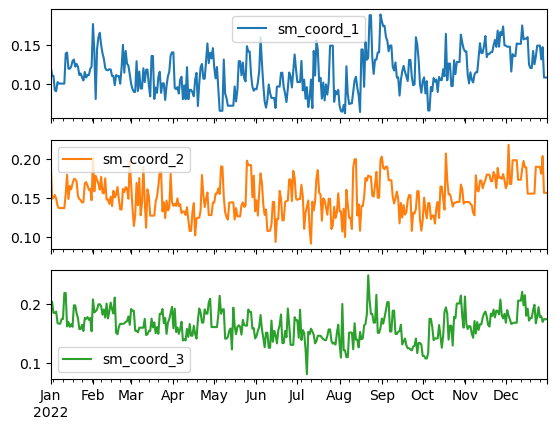

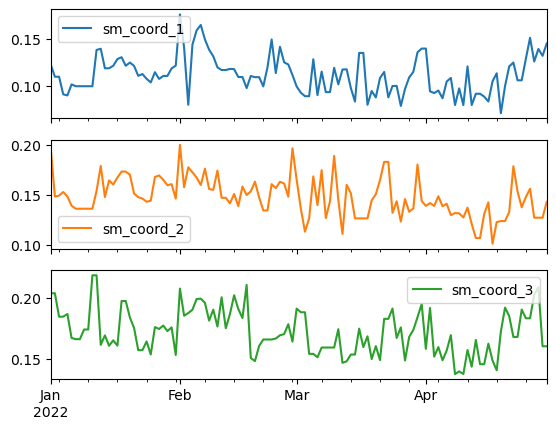

In [19]:
plot_features = sm_df
plot_features.index = l3_sm[:, 0]
_ = plot_features.plot(subplots=True)

plot_features = sm_df[:120]
plot_features.index = l3_sm[:120, 0]
_ = plot_features.plot(subplots=True)

# Next Steps Part 2 #

1. Feature Engineering: Add features such as mean, min, and max for each entry in the dataframe
2. Difference the data - want to eliminate seasonality and trend